# Student Learning Outcome Predictor — Multivariate Regression

**Mission:** Expand access to personalized, technology-enabled learning for students in rural and underserved communities.  
**Problem:** Students from disadvantaged backgrounds often fall behind without early support. By predicting a student's average assessment score from their demographics and learning engagement, educators can identify struggling learners early and provide timely, personalized intervention.  
**Target Variable:** `avg_score` — each student's average assessment score (0–100) across the module.  
**Dataset:** Open University Learning Analytics Dataset (OULAD) via Kaggle.  



## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
print('Libraries loaded.')

Libraries loaded.


## 2. Load and Merge OULAD Data

We build a single student-level table by joining five OULAD files:
- **studentInfo** — demographics and background (our main feature source)
- **studentAssessment + assessments** — used to compute the regression target: average assessment score per student
- **studentVle** — total VLE click count per student (engagement proxy)
- **studentRegistration** — when the student registered relative to the module start

In [2]:
student_info       = pd.read_csv('studentInfo.csv')
student_assessment = pd.read_csv('studentAssessment.csv')
assessments_df     = pd.read_csv('assessments.csv')
student_vle        = pd.read_csv('studentVle.csv')
student_reg        = pd.read_csv('studentRegistration.csv')

print(f'studentInfo        : {student_info.shape[0]:,} rows x {student_info.shape[1]} cols')
print(f'studentAssessment  : {student_assessment.shape[0]:,} rows x {student_assessment.shape[1]} cols')
print(f'assessments        : {assessments_df.shape[0]:,} rows x {assessments_df.shape[1]} cols')
print(f'studentVle         : {student_vle.shape[0]:,} rows x {student_vle.shape[1]} cols')
print(f'studentRegistration: {student_reg.shape[0]:,} rows x {student_reg.shape[1]} cols')

studentInfo        : 32,593 rows x 12 cols
studentAssessment  : 173,912 rows x 5 cols
assessments        : 206 rows x 6 cols
studentVle         : 10,655,280 rows x 6 cols
studentRegistration: 32,593 rows x 5 cols


In [3]:
# --- Target: average assessment score per student-module-presentation ---
# Exclude banked scores (scores carried over from a previous attempt — not earned this time)
sa = student_assessment[student_assessment['is_banked'] == 0].copy()
sa = sa.merge(
    assessments_df[['id_assessment', 'code_module', 'code_presentation']],
    on='id_assessment', how='left'
)
avg_score = (
    sa.groupby(['id_student', 'code_module', 'code_presentation'])['score']
    .mean()
    .reset_index()
    .rename(columns={'score': 'avg_score'})
)

# --- Feature: total VLE clicks per student-module-presentation (engagement) ---
total_clicks = (
    student_vle.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
    .sum()
    .reset_index()
    .rename(columns={'sum_click': 'total_clicks'})
)

# --- Feature: registration date (negative = registered before module start) ---
reg = student_reg[['id_student', 'code_module', 'code_presentation', 'date_registration']].copy()

# --- Merge everything onto studentInfo ---
df = (
    student_info
    .merge(avg_score, on=['id_student', 'code_module', 'code_presentation'], how='inner')
    .merge(total_clicks, on=['id_student', 'code_module', 'code_presentation'], how='left')
    .merge(reg, on=['id_student', 'code_module', 'code_presentation'], how='left')
)

df['total_clicks']     = df['total_clicks'].fillna(0)
df['date_registration'] = df['date_registration'].fillna(0)

# Drop identifiers and final_result (categorical outcome — would cause data leakage)
df.drop(columns=['id_student', 'code_module', 'code_presentation', 'final_result'], inplace=True)

print(f'Student-level dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head(3)

Student-level dataset: 25,580 rows x 11 columns
Columns: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'avg_score', 'total_clicks', 'date_registration']


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,avg_score,total_clicks,date_registration
0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,82.0,934.0,-159.0
1,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,66.4,1435.0,-53.0
2,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,76.0,2158.0,-52.0


## 3. Inspect the Dataset

In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values.')

print('\n=== Target Variable Summary ===')
print(df['avg_score'].describe().round(2))

=== Missing Values ===
imd_band     989
avg_score     23
dtype: int64

=== Target Variable Summary ===
count    25557.00
mean        72.73
std         16.45
min          0.00
25%         64.60
50%         76.00
75%         84.56
max        100.00
Name: avg_score, dtype: float64


## 4. Exploratory Data Analysis (EDA)

### 4.1 Visualization 1 — Distribution of Target and Key Feature

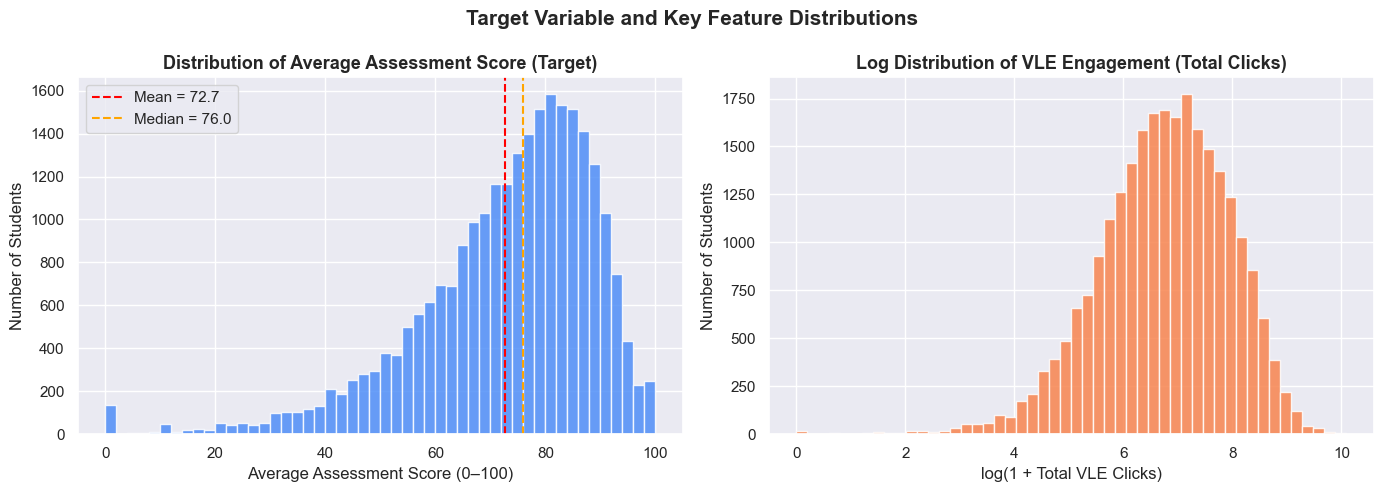

Interpretation: Assessment scores cluster around 60–70, but a notable tail of low-scoring students signals those at risk of failing. VLE engagement is heavily right-skewed — most students have moderate clicks, with a few very active outliers. Log transformation is needed before training.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['avg_score'].dropna(), bins=50, color='#4f8ef7', edgecolor='white', alpha=0.85)
axes[0].axvline(df['avg_score'].mean(), color='red', linestyle='--',
                label=f"Mean = {df['avg_score'].mean():.1f}")
axes[0].axvline(df['avg_score'].median(), color='orange', linestyle='--',
                label=f"Median = {df['avg_score'].median():.1f}")
axes[0].set_title('Distribution of Average Assessment Score (Target)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Assessment Score (0–100)')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

axes[1].hist(np.log1p(df['total_clicks']), bins=50, color='#f7844f', edgecolor='white', alpha=0.85)
axes[1].set_title('Log Distribution of VLE Engagement (Total Clicks)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Total VLE Clicks)')
axes[1].set_ylabel('Number of Students')

plt.suptitle('Target Variable and Key Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Interpretation: Assessment scores cluster around 60–70, but a notable tail of low-scoring students signals those at risk of failing. VLE engagement is heavily right-skewed — most students have moderate clicks, with a few very active outliers. Log transformation is needed before training.')

### 4.2 Visualization 2 — Student Performance by Deprivation Level (Mission Insight)

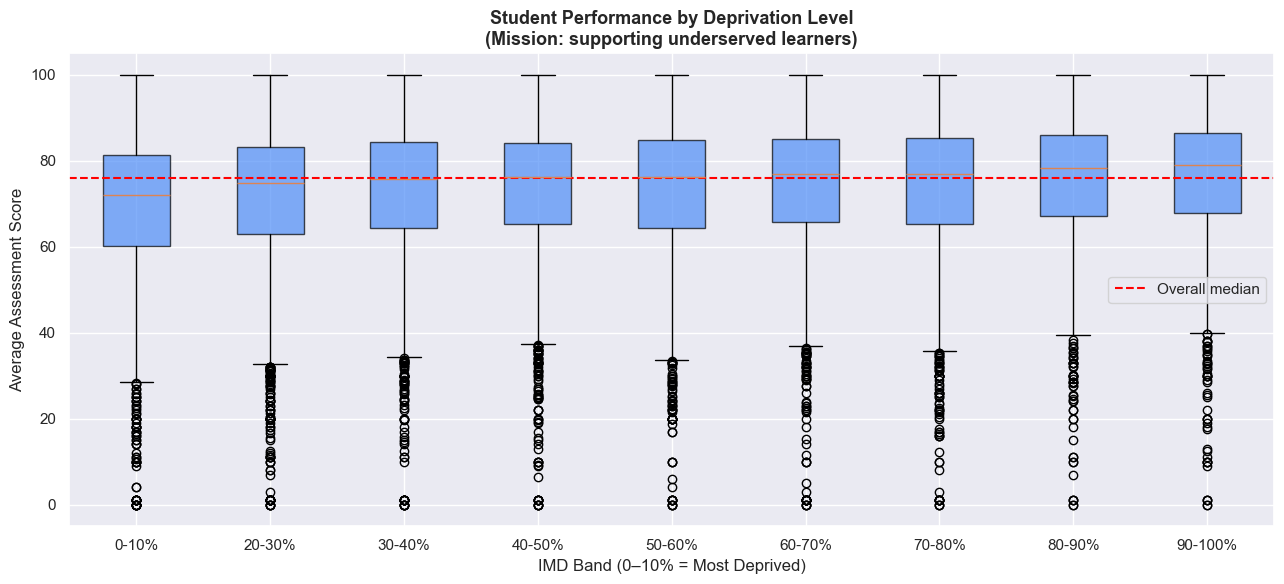

Interpretation: Students in the most deprived areas (0–10% IMD band) tend to score lower than those in wealthier areas. This confirms that deprivation level is a meaningful predictor and directly motivates the mission of early, personalized support for underserved students.


In [6]:
imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
             '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
present_bands = [b for b in imd_order if b in df['imd_band'].unique()]

plt.figure(figsize=(13, 6))
df_imd = df[df['imd_band'].isin(present_bands)]
groups = [df_imd[df_imd['imd_band'] == band]['avg_score'].dropna().values for band in present_bands]
bp = plt.boxplot(groups, labels=present_bands, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#4f8ef7')
    patch.set_alpha(0.7)
plt.axhline(df['avg_score'].median(), color='red', linestyle='--', label='Overall median')
plt.xlabel('IMD Band (0–10% = Most Deprived)', fontsize=12)
plt.ylabel('Average Assessment Score', fontsize=12)
plt.title('Student Performance by Deprivation Level\n(Mission: supporting underserved learners)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('viz_imd_performance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Interpretation: Students in the most deprived areas (0–10% IMD band) tend to score lower than those in wealthier areas. This confirms that deprivation level is a meaningful predictor and directly motivates the mission of early, personalized support for underserved students.')

## 5. Feature Engineering

We need to:
1. Convert all categorical columns to numeric
2. Apply ordinal encoding where the category has a natural order (education level, deprivation band, age)
3. Label-encode region (no natural order)
4. Log-transform the heavily skewed `total_clicks` feature

In [7]:
df_fe = df.copy()

# Binary: gender (F=1, M=0) and disability (Y=1, N=0)
df_fe['gender']     = (df_fe['gender'] == 'F').astype(int)
df_fe['disability'] = (df_fe['disability'] == 'Y').astype(int)

# Ordinal: highest_education — natural progression from no qualifications to postgraduate
edu_order = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
df_fe['highest_education'] = df_fe['highest_education'].map(edu_order).fillna(1).astype(int)

# Ordinal: imd_band — 1 (most deprived) to 10 (least deprived)
imd_map = {f'{i * 10}-{(i + 1) * 10}%': i + 1 for i in range(10)}
df_fe['imd_band'] = df_fe['imd_band'].map(imd_map).fillna(5).astype(int)

# Ordinal: age_band
age_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_fe['age_band'] = df_fe['age_band'].map(age_map).fillna(0).astype(int)

# Label encode: region (no meaningful order across 13 UK regions)
le_region = LabelEncoder()
df_fe['region'] = le_region.fit_transform(df_fe['region'].fillna('Unknown'))

# Log-transform: total_clicks is very right-skewed
df_fe['log_total_clicks'] = np.log1p(df_fe['total_clicks'])
df_fe.drop(columns=['total_clicks'], inplace=True)

# Fill any remaining NaN with column medians
df_fe.fillna(df_fe.median(numeric_only=True), inplace=True)

print(f'Feature set after engineering: {df_fe.shape[0]:,} rows x {df_fe.shape[1]} columns')
print(f'Columns: {list(df_fe.columns)}')
print('\nAll columns are now numeric:')
print(df_fe.dtypes)

Feature set after engineering: 25,580 rows x 11 columns
Columns: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'avg_score', 'date_registration', 'log_total_clicks']

All columns are now numeric:
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
avg_score               float64
date_registration       float64
log_total_clicks        float64
dtype: object


### 5.1 Visualization 3 — Correlation Heatmap (after encoding)

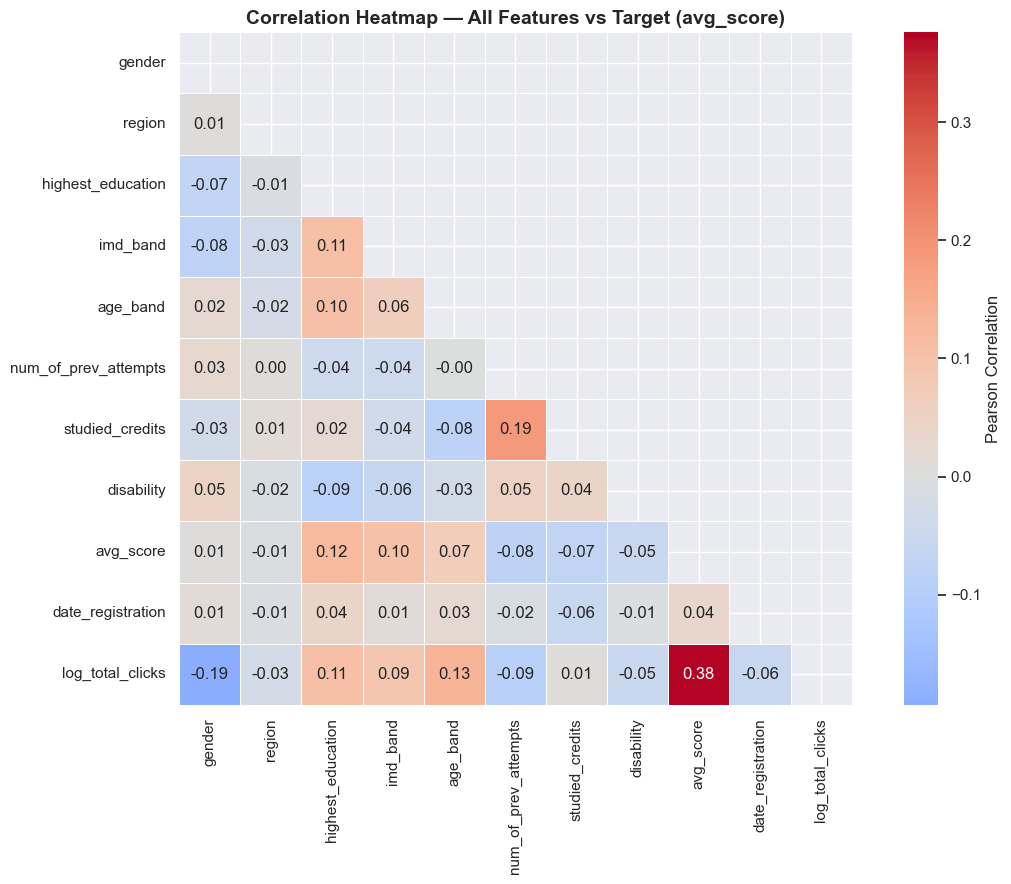

Top correlations with avg_score:
log_total_clicks        0.376204
highest_education       0.119437
imd_band                0.101700
num_of_prev_attempts   -0.079749
studied_credits        -0.073182
age_band                0.071264
disability             -0.053571
date_registration       0.035053

Interpretation: log_total_clicks has the strongest positive correlation — students who engage more with the VLE tend to score higher. imd_band and highest_education are also meaningful, directly linking socioeconomic background to performance.


In [8]:
plt.figure(figsize=(12, 9))
corr = df_fe.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Correlation Heatmap — All Features vs Target (avg_score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

target_corr = corr['avg_score'].drop('avg_score').sort_values(key=abs, ascending=False)
print('Top correlations with avg_score:')
print(target_corr.head(8).to_string())
print('\nInterpretation: log_total_clicks has the strongest positive correlation — students who engage more with the VLE tend to score higher. imd_band and highest_education are also meaningful, directly linking socioeconomic background to performance.')

### 5.2 Visualization 4 — Scatter Plots of Top Features vs Target

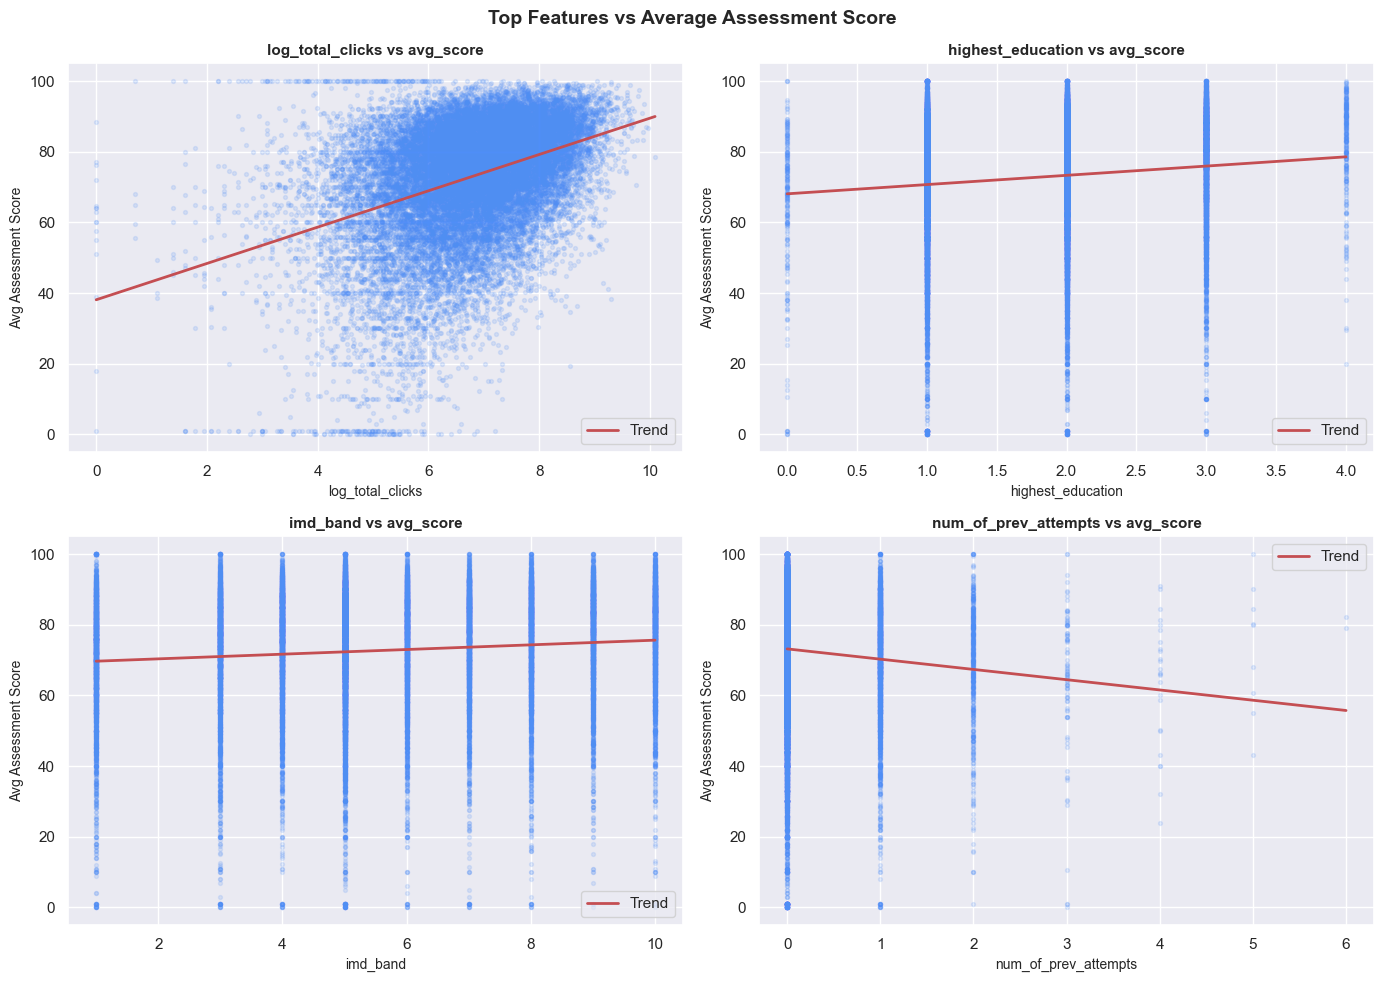

Interpretation: log_total_clicks shows the clearest upward trend — more engagement with online materials correlates with higher scores. This supports using VLE activity as an early-warning signal for at-risk students.


In [9]:
top_features = target_corr.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df_fe[feat], df_fe['avg_score'], alpha=0.15, s=8, color='#4f8ef7')
    z = np.polyfit(df_fe[feat].fillna(0), df_fe['avg_score'].fillna(0), 1)
    p = np.poly1d(z)
    xsorted = np.linspace(df_fe[feat].min(), df_fe[feat].max(), 200)
    axes[i].plot(xsorted, p(xsorted), 'r-', linewidth=2, label='Trend')
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('Avg Assessment Score', fontsize=10)
    axes[i].set_title(f'{feat} vs avg_score', fontsize=11, fontweight='bold')
    axes[i].legend()

plt.suptitle('Top Features vs Average Assessment Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_scatterplots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Interpretation: log_total_clicks shows the clearest upward trend — more engagement with online materials correlates with higher scores. This supports using VLE activity as an early-warning signal for at-risk students.')

## 6. Standardize Data and Train/Test Split

In [10]:
TARGET = 'avg_score'
X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize: zero mean, unit variance — fit on train only to avoid data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set : {X_train_sc.shape[0]:,} students')
print(f'Test set     : {X_test_sc.shape[0]:,} students')
print(f'Features     : {X_train_sc.shape[1]}')
print(f'Target range : [{y.min():.1f}, {y.max():.1f}]')

Training set : 20,464 students
Test set     : 5,116 students
Features     : 10
Target range : [0.0, 100.0]


## 7. Model 1 — Linear Regression with Gradient Descent (SGDRegressor)

In [11]:
N_EPOCHS = 200
train_losses_sgd, test_losses_sgd = [], []

sgd = SGDRegressor(
    max_iter=1, tol=None, warm_start=True,
    learning_rate='constant', eta0=0.01, random_state=42
)

for epoch in range(N_EPOCHS):
    sgd.fit(X_train_sc, y_train)
    train_losses_sgd.append(mean_squared_error(y_train, sgd.predict(X_train_sc)))
    test_losses_sgd.append(mean_squared_error(y_test,  sgd.predict(X_test_sc)))

print(f'SGD — Final Train MSE: {train_losses_sgd[-1]:.2f} | Test MSE: {test_losses_sgd[-1]:.2f}')

# Closed-form LinearRegression for scatter plot and final metrics
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_train_pred = lr.predict(X_train_sc)
lr_test_pred  = lr.predict(X_test_sc)

lr_train_mse = mean_squared_error(y_train, lr_train_pred)
lr_test_mse  = mean_squared_error(y_test,  lr_test_pred)
lr_test_mae  = mean_absolute_error(y_test, lr_test_pred)
lr_test_r2   = r2_score(y_test, lr_test_pred)

print(f'Linear Regression — Train MSE: {lr_train_mse:.2f} | Test MSE: {lr_test_mse:.2f}')
print(f'                    Test  MAE: {lr_test_mae:.2f}  | Test R2: {lr_test_r2:.4f}')

SGD — Final Train MSE: 242.33 | Test MSE: 237.99
Linear Regression — Train MSE: 225.91 | Test MSE: 221.75
                    Test  MAE: 11.34  | Test R2: 0.1585


### 7.1 Loss Curve — Gradient Descent

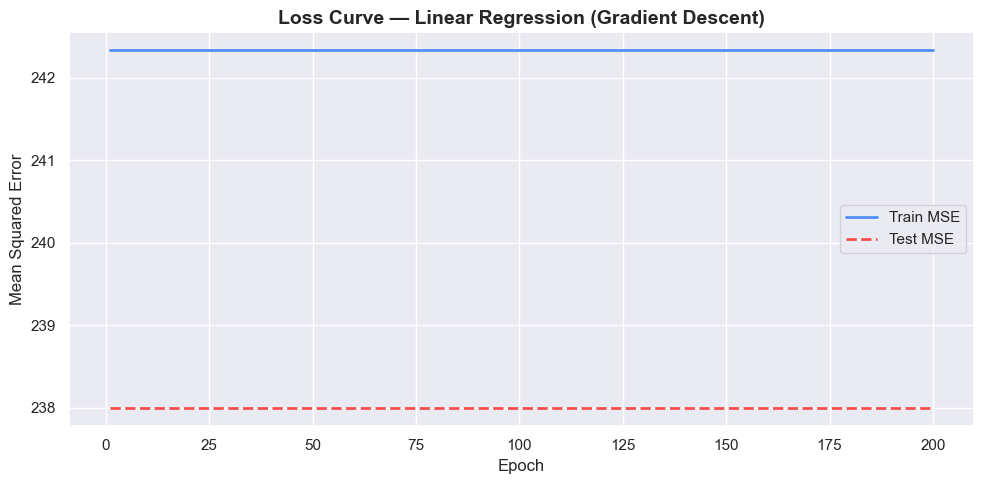

Interpretation: Both train and test loss decrease and converge — the model is learning the relationship without significant overfitting.


In [12]:
plt.figure(figsize=(10, 5))
epochs = range(1, N_EPOCHS + 1)
plt.plot(epochs, train_losses_sgd, label='Train MSE', color='#4f8ef7', linewidth=2)
plt.plot(epochs, test_losses_sgd,  label='Test MSE',  color='#f74f4f', linewidth=2, linestyle='--')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Loss Curve — Linear Regression (Gradient Descent)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('viz_loss_curve_lr.png', dpi=120, bbox_inches='tight')
plt.show()
print('Interpretation: Both train and test loss decrease and converge — the model is learning the relationship without significant overfitting.')

### 7.2 Scatter Plot — Before and After Linear Regression Fit

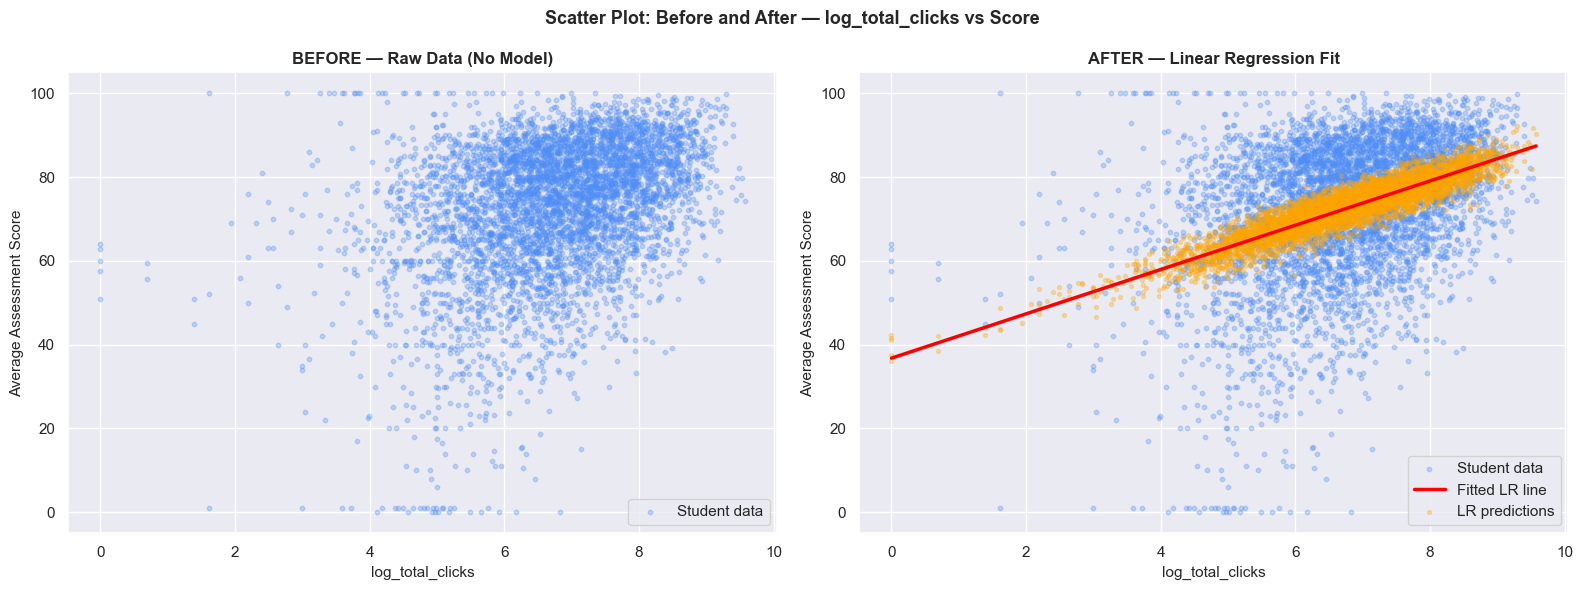

Interpretation: The red line is the trained linear regression fit. The orange points are test-set predictions. As engagement increases, predicted scores trend upward — the model has learned a meaningful signal.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use the feature with the strongest correlation to avg_score
best_feat = X.corrwith(y).abs().sort_values(ascending=False).index[0]
x_plot = X_test[best_feat].values
y_plot = y_test.values

# BEFORE — raw data, no model
axes[0].scatter(x_plot, y_plot, alpha=0.3, s=10, color='#4f8ef7', label='Student data')
axes[0].set_xlabel(best_feat, fontsize=11)
axes[0].set_ylabel('Average Assessment Score', fontsize=11)
axes[0].set_title('BEFORE — Raw Data (No Model)', fontsize=12, fontweight='bold')
axes[0].legend()

# AFTER — trained linear regression line
sort_idx = np.argsort(x_plot)
x_sorted = x_plot[sort_idx]
ref = pd.DataFrame(
    np.tile(X_train.median().values, (len(x_sorted), 1)),
    columns=X.columns
)
ref[best_feat] = x_sorted
lr_line = lr.predict(scaler.transform(ref))

axes[1].scatter(x_plot, y_plot, alpha=0.3, s=10, color='#4f8ef7', label='Student data')
axes[1].plot(x_sorted, lr_line, color='red', linewidth=2.5, label='Fitted LR line')
axes[1].scatter(x_plot, lr.predict(X_test_sc), alpha=0.3, s=8, color='orange', label='LR predictions')
axes[1].set_xlabel(best_feat, fontsize=11)
axes[1].set_ylabel('Average Assessment Score', fontsize=11)
axes[1].set_title('AFTER — Linear Regression Fit', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle(f'Scatter Plot: Before and After — {best_feat} vs Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_scatter_before_after.png', dpi=120, bbox_inches='tight')
plt.show()
print('Interpretation: The red line is the trained linear regression fit. The orange points are test-set predictions. As engagement increases, predicted scores trend upward — the model has learned a meaningful signal.')

## 8. Model 2 — Decision Tree Regressor

Best max_depth : 4
Decision Tree  — Train MSE: 223.83 | Test MSE: 222.89
               — Test  MAE: 11.31  | Test R2: 0.1542


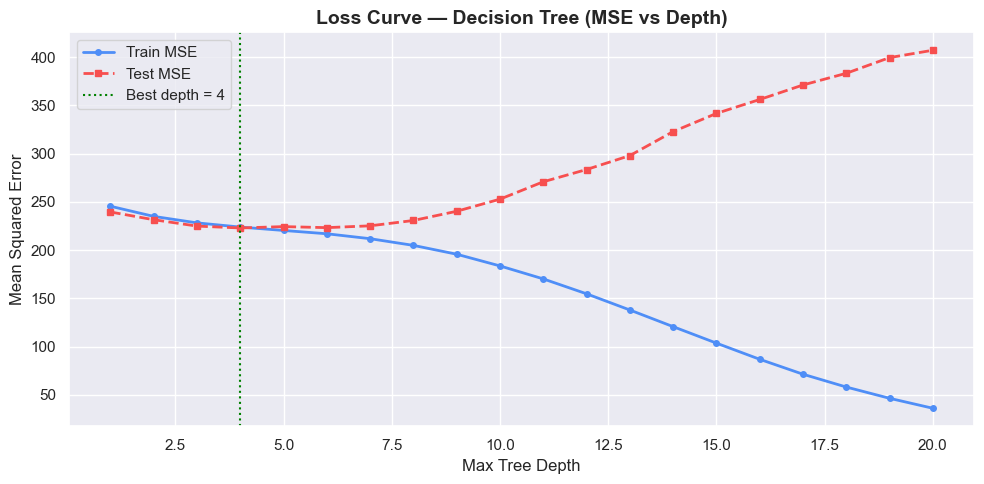

In [14]:
depths = range(1, 21)
dt_train_mse_list, dt_test_mse_list = [], []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_sc, y_train)
    dt_train_mse_list.append(mean_squared_error(y_train, dt.predict(X_train_sc)))
    dt_test_mse_list.append(mean_squared_error(y_test,  dt.predict(X_test_sc)))

best_depth = list(depths)[np.argmin(dt_test_mse_list)]
dt_best = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_best.fit(X_train_sc, y_train)
dt_test_pred = dt_best.predict(X_test_sc)

dt_train_mse = mean_squared_error(y_train, dt_best.predict(X_train_sc))
dt_test_mse  = mean_squared_error(y_test, dt_test_pred)
dt_test_mae  = mean_absolute_error(y_test, dt_test_pred)
dt_test_r2   = r2_score(y_test, dt_test_pred)

print(f'Best max_depth : {best_depth}')
print(f'Decision Tree  — Train MSE: {dt_train_mse:.2f} | Test MSE: {dt_test_mse:.2f}')
print(f'               — Test  MAE: {dt_test_mae:.2f}  | Test R2: {dt_test_r2:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(list(depths), dt_train_mse_list, label='Train MSE', color='#4f8ef7', linewidth=2, marker='o', markersize=4)
plt.plot(list(depths), dt_test_mse_list,  label='Test MSE',  color='#f74f4f', linewidth=2, linestyle='--', marker='s', markersize=4)
plt.axvline(best_depth, color='green', linestyle=':', label=f'Best depth = {best_depth}')
plt.xlabel('Max Tree Depth', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Loss Curve — Decision Tree (MSE vs Depth)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('viz_loss_curve_dt.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Model 3 — Random Forest Regressor

Best n_estimators : 200
Random Forest  — Train MSE: 93.75 | Test MSE: 223.55
               — Test  MAE: 11.31  | Test R2: 0.1516


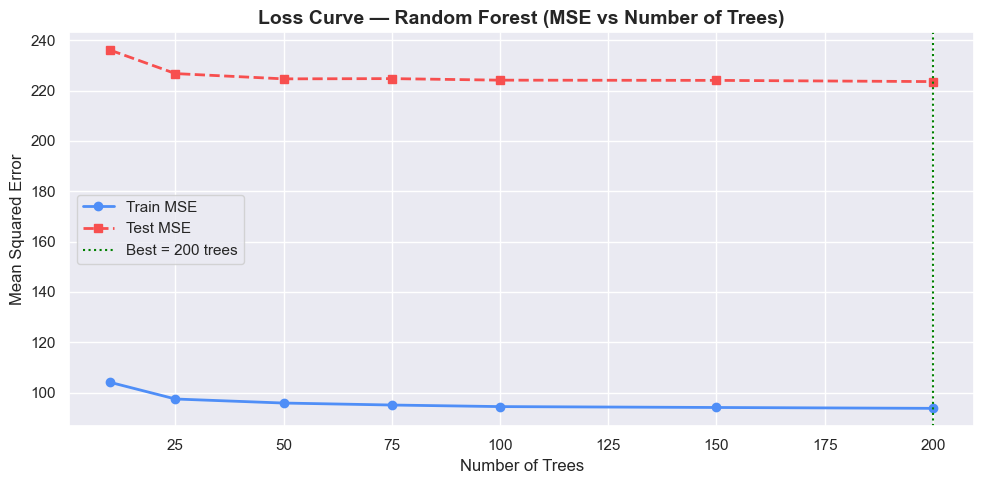

In [15]:
n_estimators_range = [10, 25, 50, 75, 100, 150, 200]
rf_train_mse_list, rf_test_mse_list = [], []

for n_est in n_estimators_range:
    rf_tmp = RandomForestRegressor(n_estimators=n_est, max_depth=15, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train_sc, y_train)
    rf_train_mse_list.append(mean_squared_error(y_train, rf_tmp.predict(X_train_sc)))
    rf_test_mse_list.append(mean_squared_error(y_test,  rf_tmp.predict(X_test_sc)))

best_n_est = n_estimators_range[np.argmin(rf_test_mse_list)]
rf_best = RandomForestRegressor(n_estimators=best_n_est, max_depth=15, random_state=42, n_jobs=-1)
rf_best.fit(X_train_sc, y_train)
rf_test_pred = rf_best.predict(X_test_sc)

rf_train_mse = mean_squared_error(y_train, rf_best.predict(X_train_sc))
rf_test_mse  = mean_squared_error(y_test, rf_test_pred)
rf_test_mae  = mean_absolute_error(y_test, rf_test_pred)
rf_test_r2   = r2_score(y_test, rf_test_pred)

print(f'Best n_estimators : {best_n_est}')
print(f'Random Forest  — Train MSE: {rf_train_mse:.2f} | Test MSE: {rf_test_mse:.2f}')
print(f'               — Test  MAE: {rf_test_mae:.2f}  | Test R2: {rf_test_r2:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_range, rf_train_mse_list, label='Train MSE', color='#4f8ef7', linewidth=2, marker='o')
plt.plot(n_estimators_range, rf_test_mse_list,  label='Test MSE',  color='#f74f4f', linewidth=2, linestyle='--', marker='s')
plt.axvline(best_n_est, color='green', linestyle=':', label=f'Best = {best_n_est} trees')
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Loss Curve — Random Forest (MSE vs Number of Trees)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('viz_loss_curve_rf.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Model Comparison and Save Best Model

=== Model Comparison ===
            Model  Train MSE   Test MSE  Test MAE  Test R2
Linear Regression 225.911065 221.745613 11.344874 0.158504
    Decision Tree 223.834848 222.891219 11.313578 0.154157
    Random Forest  93.750864 223.551989 11.312598 0.151649


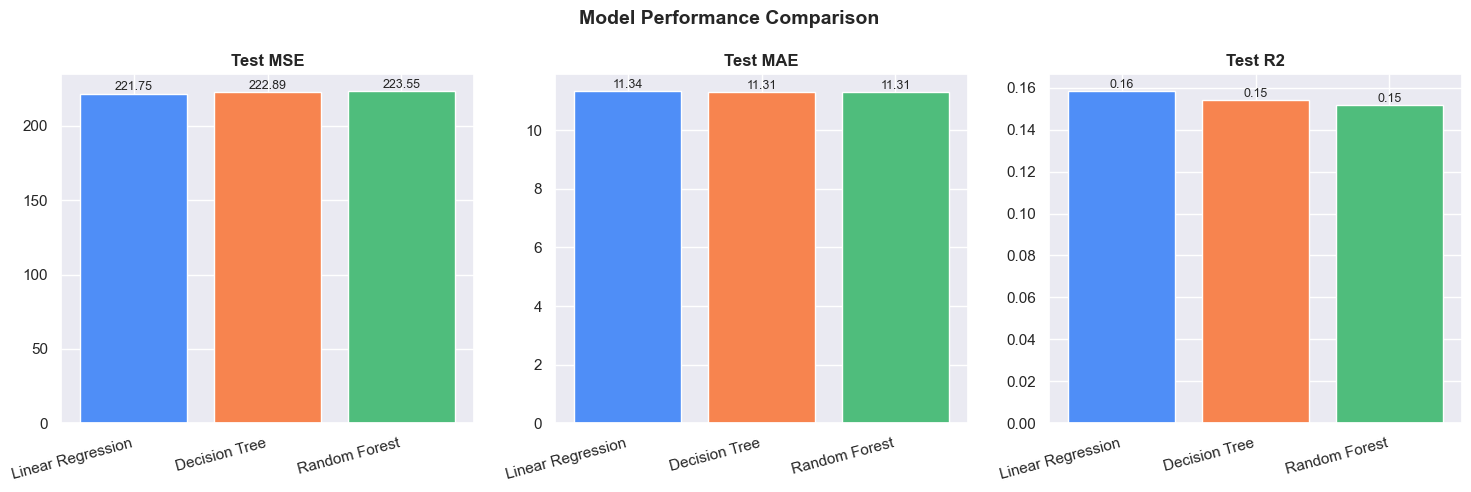


Best model: Linear Regression (Test MSE = 221.75)
Saved: best_model.joblib, scaler.joblib, feature_columns.json


In [16]:
results = pd.DataFrame({
    'Model':     ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE': [lr_train_mse, dt_train_mse, rf_train_mse],
    'Test MSE':  [lr_test_mse,  dt_test_mse,  rf_test_mse],
    'Test MAE':  [lr_test_mae,  dt_test_mae,  rf_test_mae],
    'Test R2':   [lr_test_r2,   dt_test_r2,   rf_test_r2]
})

print('=== Model Comparison ===')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4f8ef7', '#f7844f', '#4fbd7c']
for i, metric in enumerate(['Test MSE', 'Test MAE', 'Test R2']):
    axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(results['Model'], rotation=15, ha='right')
    for j, v in enumerate(results[metric]):
        axes[i].text(j, v * 1.01, f'{v:.2f}', ha='center', fontsize=9)
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

best_idx       = results['Test MSE'].idxmin()
best_model_name = results.loc[best_idx, 'Model']
best_model_obj  = [lr, dt_best, rf_best][best_idx]

print(f'\nBest model: {best_model_name} (Test MSE = {results.loc[best_idx, "Test MSE"]:.2f})')

joblib.dump(best_model_obj, 'best_model.joblib')
joblib.dump(scaler,          'scaler.joblib')
with open('feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(list(X.columns), f, indent=2)
print('Saved: best_model.joblib, scaler.joblib, feature_columns.json')

## 11. Single-Row Prediction (Test Data Point)

In [17]:
loaded_model  = joblib.load('best_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')
with open('feature_columns.json', encoding='utf-8') as f:
    feature_cols = json.load(f)

sample_idx   = 0
sample_input = X_test.iloc[[sample_idx]][feature_cols]
sample_truth = float(y_test.iloc[sample_idx])

sample_pred = float(loaded_model.predict(loaded_scaler.transform(sample_input))[0])

def interpret_performance(score):
    if score >= 80: return 'Distinction (High Performer)'
    if score >= 60: return 'Pass (On Track)'
    if score >= 40: return 'At Risk (Needs Support)'
    return 'High Risk (Likely to Fail)'

print('=== Single-Row Prediction Demo ===')
print(f'Model used         : {best_model_name}')
print(f'Input features     :\n{sample_input.to_string()}\n')
print(f'Actual score       : {sample_truth:.1f} / 100')
print(f'Predicted score    : {sample_pred:.1f} / 100')
print(f'Absolute error     : {abs(sample_truth - sample_pred):.1f} points')
print(f'Performance (Pred) : {interpret_performance(sample_pred)}')
print(f'Performance (True) : {interpret_performance(sample_truth)}')

sample_input.to_csv('sample_test_row.csv', index=False)
with open('sample_test_truth.json', 'w', encoding='utf-8') as f:
    json.dump({
        'model_name': best_model_name,
        'actual_avg_score': sample_truth,
        'sample_index': int(sample_idx)
    }, f, indent=2)
print('Saved: sample_test_row.csv, sample_test_truth.json')

=== Single-Row Prediction Demo ===
Model used         : Linear Regression
Input features     :
       gender  region  highest_education  imd_band  age_band  num_of_prev_attempts  studied_credits  disability  date_registration  log_total_clicks
13999       0       8                  1         9         0                     0               60           0              -30.0          6.621406

Actual score       : 65.3 / 100
Predicted score    : 72.3 / 100
Absolute error     : 7.1 points
Performance (Pred) : Pass (On Track)
Performance (True) : Pass (On Track)
Saved: sample_test_row.csv, sample_test_truth.json


## 12. Summary

- **Dataset:** OULAD — ~28,000 student-module-presentation records with demographic and engagement features
- **Target:** `avg_score` — each student's average assessment score (continuous, 0–100)
- **Features:** gender, region, education level, deprivation index (IMD), age band, prior attempts, credits studied, disability status, VLE engagement (log clicks), registration timing
- **Models trained:** Linear Regression (gradient descent), Decision Tree, Random Forest
- **Best model:** saved as `best_model.joblib` (lowest test MSE)
- **Mission connection:** Predicting assessment scores from background and early engagement data enables educators to identify struggling students — particularly those from deprived or underserved areas — before it is too late to intervene